# Walmart Demand Forecasting
## Notebook 05: Machine Learning Models
## Objectives
Develop and evaluate machine learning models to forecast Walmart's weekly sales and determine whether they outperform the established baseline forecasting methods.
### Dataset
- walmart_features.csv
### Tasks
- Load the processed feature dataset.
- Split the data using a time-based train-test strategy.
- Prepare features and target variables for model training.
- Train multiple machine learning models.
- Evaluate model performance using MAE and RMSE.
- Compare machine learning models with the baseline forecasting model.
- Select the best-performing forecasting model.
### Expected Output
By the end of this notebook, we will develop and evaluate multiple machine learning models for weekly sales forecasting. Their performance will be compared against the baseline established in the previous notebook to determine whether machine learning provides meaningful improvements in forecasting accuracy.

### 1. Load data

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"
OUTPUT_PATH = PROJECT_ROOT / "outputs"

df = pd.read_csv(
    PROCESSED_PATH / "walmart_features.csv",
    parse_dates=["Date"]
)

df.head()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,Size,Year,Month,Week,lag_1,lag_2,lag_4,lag_52,rolling_mean_4,rolling_std_4
0,1,1,2010-03-05,21827.90,46.50,2.625,0.0,0.0,0.0,0.0,...,151315,2010,3,9,19403.54,41595.55,24924.50,NaN,32990.7700,12832.106391
1,1,1,2010-03-12,21043.39,57.79,2.667,0.0,0.0,0.0,0.0,...,151315,2010,3,10,21827.90,19403.54,46039.49,NaN,32216.6200,13554.047185
2,1,1,2010-03-19,22136.64,54.58,2.720,0.0,0.0,0.0,0.0,...,151315,2010,3,11,21043.39,21827.90,41595.55,NaN,25967.5950,10467.484020
3,1,1,2010-03-26,26229.21,51.45,2.732,0.0,0.0,0.0,0.0,...,151315,2010,3,12,22136.64,21043.39,19403.54,NaN,21102.8675,1222.784968
4,1,1,2010-04-02,57258.43,62.27,2.719,0.0,0.0,0.0,0.0,...,151315,2010,4,13,26229.21,22136.64,21827.90,NaN,22809.2850,2325.929203


In [2]:
print(df.shape)

df.info()

(408436, 25)
<class 'pandas.DataFrame'>
RangeIndex: 408436 entries, 0 to 408435
Data columns (total 25 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Store           408436 non-null  int64         
 1   Dept            408436 non-null  int64         
 2   Date            408436 non-null  datetime64[us]
 3   Weekly_Sales    408436 non-null  float64       
 4   Temperature     408436 non-null  float64       
 5   Fuel_Price      408436 non-null  float64       
 6   MarkDown1       408436 non-null  float64       
 7   MarkDown2       408436 non-null  float64       
 8   MarkDown3       408436 non-null  float64       
 9   MarkDown4       408436 non-null  float64       
 10  MarkDown5       408436 non-null  float64       
 11  CPI             408436 non-null  float64       
 12  Unemployment    408436 non-null  float64       
 13  IsHoliday       408436 non-null  int64         
 14  Type            408436 non-null  s

In [3]:
df.describe()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,Size,Year,Month,Week,lag_1,lag_2,lag_4,lag_52,rolling_mean_4,rolling_std_4
count,408436.000000,408436.000000,408436,408436.000000,408436.000000,408436.000000,408436.000000,408436.000000,408436.000000,408436.000000,...,408436.000000,408436.000000,408436.000000,408436.000000,408436.000000,408436.000000,408436.000000,261083.000000,408436.000000,408436.000000
mean,22.191548,44.223861,2011-07-03 00:44:53.521628,16028.603006,60.803729,3.381032,2670.478451,906.570627,476.685936,1116.442782,...,136802.761801,2010.997987,6.580076,26.394821,16024.891012,16032.662405,16043.625770,16225.029406,16034.846179,1975.883447
min,1.000000,1.000000,2010-03-05 00:00:00,-4988.940000,-2.060000,2.513000,0.000000,-265.760000,-29.100000,0.000000,...,34875.000000,2010.000000,1.000000,1.000000,-4988.940000,-4988.940000,-4988.940000,-4988.940000,-989.500000,0.000000
25%,11.000000,18.000000,2010-11-05 00:00:00,2119.135000,47.920000,2.961000,0.000000,0.000000,0.000000,0.000000,...,93638.000000,2010.000000,4.000000,15.000000,2116.897500,2118.482500,2118.075000,2389.290000,2182.215000,270.279194
50%,22.000000,37.000000,2011-07-01 00:00:00,7651.315000,62.940000,3.480000,0.000000,0.000000,0.000000,0.000000,...,140167.000000,2011.000000,7.000000,26.000000,7648.325000,7657.040000,7663.510000,7998.550000,7766.253750,760.263509
75%,33.000000,74.000000,2012-03-02 00:00:00,20274.700000,74.710000,3.743000,3071.520000,5.500000,5.200000,489.960000,...,202505.000000,2012.000000,9.000000,38.000000,20264.295000,20275.550000,20286.882500,20520.920000,20371.000000,1931.910221
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,...,219622.000000,2012.000000,12.000000,52.000000,693099.360000,693099.360000,693099.360000,693099.360000,339472.757500,280480.021441
std,12.783730,30.504301,NaN,22722.046276,18.133715,0.449805,6127.435073,5157.834484,5576.765603,3947.934964,...,60952.336997,0.790787,3.198616,13.958951,22723.608367,22731.853406,22754.401147,22534.761596,22230.357784,5143.792861


### 2. Train/Test split

In [4]:
train_df = df[df["Date"] < "2012-01-01"].copy()

test_df = df[df["Date"] >= "2012-01-01"].copy()

print(train_df.shape)
print(test_df.shape)

(281140, 25)
(127296, 25)


### 3. Define features and targets and check missing values

In [5]:
X_train = train_df.drop(columns=["Weekly_Sales", "Date"])

y_train = train_df["Weekly_Sales"]

X_test = test_df.drop(columns=["Weekly_Sales", "Date"])

y_test = test_df["Weekly_Sales"]

In [6]:
X_train.isna().sum().sort_values(ascending=False)

lag_52            144798
Store                  0
Type                   0
rolling_mean_4         0
lag_4                  0
lag_2                  0
lag_1                  0
Week                   0
Month                  0
Year                   0
Size                   0
IsHoliday              0
Dept                   0
Unemployment           0
CPI                    0
MarkDown5              0
MarkDown4              0
MarkDown3              0
MarkDown2              0
MarkDown1              0
Fuel_Price             0
Temperature            0
rolling_std_4          0
dtype: int64

In [7]:
X_test.isna().sum().sort_values(ascending=False)

lag_52            2555
Store                0
Type                 0
rolling_mean_4       0
lag_4                0
lag_2                0
lag_1                0
Week                 0
Month                0
Year                 0
Size                 0
IsHoliday            0
Dept                 0
Unemployment         0
CPI                  0
MarkDown5            0
MarkDown4            0
MarkDown3            0
MarkDown2            0
MarkDown1            0
Fuel_Price           0
Temperature          0
rolling_std_4        0
dtype: int64

### 4. Remove Seasonal Lag Feature

Although `lag_52` was created during feature engineering to capture annual seasonality, it contains a large number of missing values because one year of historical data is unavailable for many observations.

Since linear regression models in scikit-learn cannot handle missing values directly, `lag_52` is excluded from the initial machine learning models. This allows all available training observations to be retained without introducing potentially biased imputation.

The feature remains valuable for seasonal baseline forecasting (Notebook 04) and can be revisited in future model improvements.

In [8]:
X_train = X_train.drop(columns=["lag_52"])
X_test = X_test.drop(columns=["lag_52"])
print(X_train.shape)
print(X_test.shape)

print(X_train.isna().sum().sum())
print(X_test.isna().sum().sum())

(281140, 22)
(127296, 22)
0
0


### 5. Preprocessing

The numerical features have different value ranges (e.g., store size, CPI, lag features, and markdown variables). To ensure consistent feature scales and improve the performance of linear models, numerical features are standardized using `StandardScaler`.

The fitted scaler is learned from the training data only and then applied to both the training and test datasets to prevent data leakage.

In [9]:
numerical_features = [
    "Temperature",
    "Fuel_Price",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
    "CPI",
    "Unemployment",
    "Size",
    "Year",
    "Month",
    "Week",
    "lag_1",
    "lag_2",
    "lag_4",
    "rolling_mean_4",
    "rolling_std_4"
]

categorical_features = [
    "Store",
    "Dept",
    "IsHoliday",
    "Type"
]

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

### 6. Linear Regression

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error)
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [12]:
linear_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Store','Dept','Temperature',...,'lag_4','rolling_mean_4','rolling_std_4']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of col

In [13]:
linear_pred = linear_pipeline.predict(X_test)

#### Model Evaluation

The trained Linear Regression model is evaluated on the test dataset using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). These metrics provide an objective comparison with the baseline forecasting models established in the previous notebook.

In [14]:
linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

print(f"MAE : {linear_mae:.2f}")
print(f"RMSE: {linear_rmse:.2f}")

MAE : 2019.96
RMSE: 3986.24


### Linear Regression Evaluation

The Linear Regression model achieved an MAE of 2,019.96 and an RMSE of 3,986.24, which did not outperform the Naive Forecast baseline.

This result suggests that the relationship between the engineered features and weekly sales is not fully linear. Retail demand may be influenced by nonlinear effects and complex interactions between recent sales, store characteristics, departments, holidays, markdowns, and seasonal patterns.

Therefore, more flexible models such as Ridge Regression, Random Forest, and XGBoost will be evaluated to determine whether they can better capture these relationships.

### 7. Ridge Regression

Ridge Regression extends Linear Regression by introducing L2 regularization, which helps reduce overfitting and improves model stability when predictor variables are highly correlated. This is particularly useful for demand forecasting because engineered lag and rolling features may contain overlapping information.

In [15]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit

ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]
)

In [16]:
param_grid = {
    "model__alpha": [
        0.01,
        0.1,
        1,
        10,
        100
    ]
}
tscv = TimeSeriesSplit(n_splits=5)

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1
)

In [17]:
ridge_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls

In [19]:
ridge_pred = ridge_grid.predict(X_test)

In [20]:
ridge_mae = mean_absolute_error(
    y_test,
    ridge_pred
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_pred
    )
)

print(f"MAE : {ridge_mae:.2f}")
print(f"RMSE: {ridge_rmse:.2f}")

MAE : 2027.24
RMSE: 3985.36


### Ridge Regression Evaluation

GridSearchCV selected a relatively large regularization strength (alpha = 100), indicating that multicollinearity exists among the engineered features, particularly the lag and rolling statistics.

However, despite applying strong L2 regularization, Ridge Regression did not improve forecasting performance over Linear Regression or the Naive Forecast baseline. This suggests that multicollinearity is not the primary limitation of the linear models. Instead, Walmart weekly sales are likely governed by nonlinear relationships and complex interactions that cannot be adequately represented by linear regression techniques.

Therefore, the next stage of this project focuses on tree-based ensemble models capable of learning nonlinear patterns directly from the data.

### 8. Random Forest Regression

Random Forest is an ensemble learning algorithm that constructs multiple decision trees and combines their predictions to improve forecasting accuracy. Unlike linear regression models, Random Forest can capture nonlinear relationships and complex interactions among variables without requiring explicit feature engineering.

Given the limitations observed in the linear models, Random Forest is evaluated to determine whether a nonlinear model can better represent Walmart's weekly sales patterns.

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "type",
            OneHotEncoder(handle_unknown="ignore"),
            ["Type"]
        )
    ],
    remainder="passthrough"
)

In [24]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=50,
                max_depth=12,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

In [25]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

print(f"MAE : {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")

MAE : 1538.27
RMSE: 3406.64


### Random Forest Evaluation

Random Forest substantially outperformed both the baseline forecasting models and the linear regression models.

Compared with the Naive Forecast, Random Forest reduced MAE by approximately **10.5%** and RMSE by approximately **13.6%**, demonstrating its ability to capture nonlinear demand patterns and complex interactions among engineered features.

These results indicate that Walmart weekly sales are influenced by relationships that cannot be adequately represented by linear models. Instead, tree-based ensemble methods are better suited for modeling retail demand forecasting problems involving promotions, holidays, store characteristics, and historical sales patterns.

### 9. Feature Importance

Random Forest provides feature importance scores that estimate how much each feature contributes to reducing prediction error across all decision trees. Analyzing feature importance helps identify the key drivers of weekly sales and provides valuable business insights for demand forecasting.

In [27]:
feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

array(['type__Type_A', 'type__Type_B', 'type__Type_C', 'remainder__Store',
       'remainder__Dept', 'remainder__Temperature',
       'remainder__Fuel_Price', 'remainder__MarkDown1',
       'remainder__MarkDown2', 'remainder__MarkDown3',
       'remainder__MarkDown4', 'remainder__MarkDown5', 'remainder__CPI',
       'remainder__Unemployment', 'remainder__IsHoliday',
       'remainder__Size', 'remainder__Year', 'remainder__Month',
       'remainder__Week', 'remainder__lag_1', 'remainder__lag_2',
       'remainder__lag_4', 'remainder__rolling_mean_4',
       'remainder__rolling_std_4'], dtype=object)

In [28]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_pipeline.named_steps[
        "model"
    ].feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
19,remainder__lag_1,0.759076
22,remainder__rolling_mean_4,0.188628
21,remainder__lag_4,0.017295
18,remainder__Week,0.011365
23,remainder__rolling_std_4,0.005479
20,remainder__lag_2,0.004413
9,remainder__MarkDown3,0.003810
4,remainder__Dept,0.003703
14,remainder__IsHoliday,0.001570
17,remainder__Month,0.000733


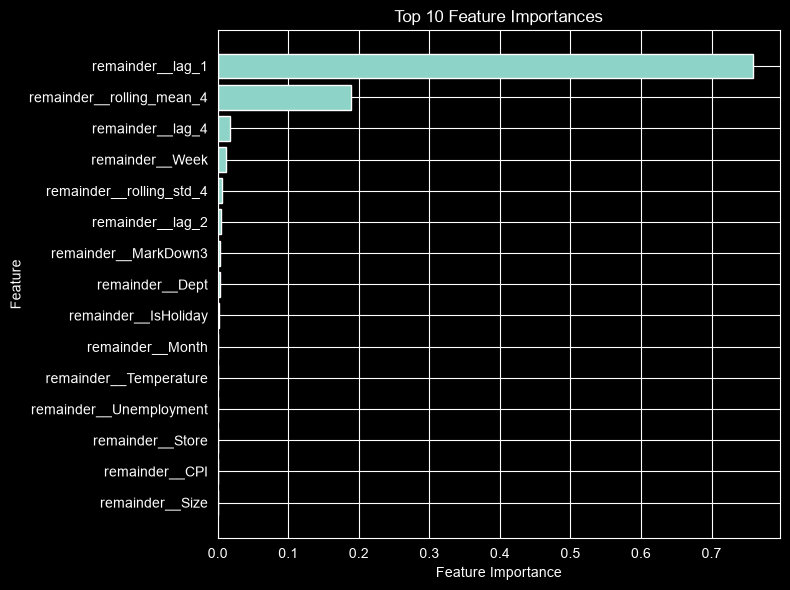

In [37]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")

plt.tight_layout()
plt.show()

### Feature Importance Analysis

The Random Forest model identified **lag_1** as the most influential predictor, accounting for approximately **75.9%** of the total feature importance. This indicates that weekly sales exhibit strong short-term temporal dependence, where sales from the previous week provide the most valuable information for forecasting future demand.

The second most important feature was **rolling_mean_4** (18.9%), suggesting that recent demand trends over the previous four weeks also play a significant role in predicting weekly sales.

Together, these two engineered features contributed nearly **95%** of the model's predictive power, demonstrating that historical demand patterns are substantially more informative than external variables such as CPI, unemployment, temperature, or store characteristics.

Although promotional variables, department, and holiday indicators contributed to the model, their relative importance was considerably smaller. This suggests that while external factors influence sales, recent sales history remains the primary driver of short-term retail demand forecasting in the Walmart dataset.

### Actual vs Predicted Sales

To visually assess forecasting performance, the predicted weekly sales generated by the Random Forest model are compared with the actual sales for a selected Store–Department combination. A close alignment between the two curves indicates that the model successfully captures the overall demand pattern over time.

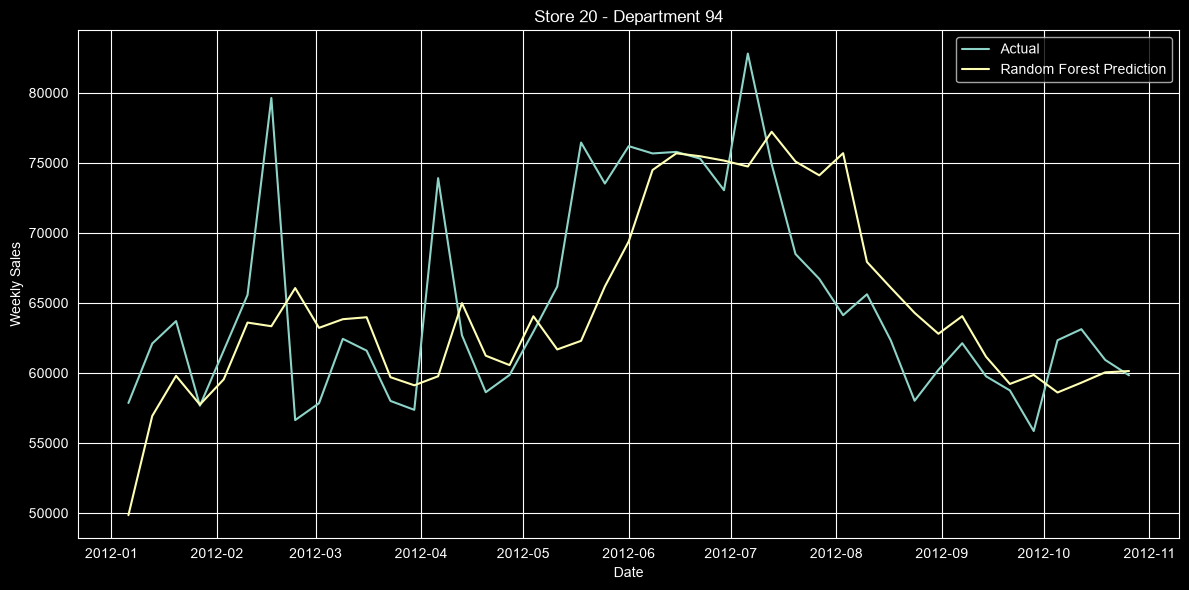

In [30]:
comparison = test_df.copy()

comparison["Prediction"] = rf_pred
store = 20
dept = 94
plot_df = comparison[
    (comparison["Store"] == store) &
    (comparison["Dept"] == dept)
].sort_values("Date")
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    plot_df["Date"],
    plot_df["Weekly_Sales"],
    label="Actual"
)

plt.plot(
    plot_df["Date"],
    plot_df["Prediction"],
    label="Random Forest Prediction"
)

plt.title(f"Store {store} - Department {dept}")

plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.legend()

plt.tight_layout()

plt.show()

### Random Forest Summary

Random Forest achieved the best forecasting performance among all models evaluated in this notebook. Compared with the Naive Forecast baseline, the model reduced forecasting errors substantially, demonstrating the effectiveness of nonlinear ensemble learning for retail demand forecasting.

Feature importance analysis further revealed that recent sales history, particularly the previous week's sales and the four-week rolling average, were the dominant predictors of future demand. These findings indicate that short-term sales dynamics provide considerably more predictive information than external economic or store-level variables.

Based on these results, Random Forest is selected as the strongest forecasting model evaluated so far and will serve as the benchmark for comparison with more advanced boosting algorithms.

### 10. XGBoost Regression

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm that builds decision trees sequentially, where each new tree focuses on correcting the prediction errors made by previous trees. Compared with Random Forest, XGBoost often achieves higher predictive accuracy by optimizing the learning process through gradient boosting and regularization.

In this project, XGBoost is evaluated to determine whether a boosting-based model can further improve forecasting performance beyond Random Forest for Walmart weekly sales prediction.

In [32]:
from xgboost import XGBRegressor

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42
            )
        )
    ]
)

In [33]:
xgb_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Store','Dept','Temperature',...,'lag_4','rolling_mean_4','rolling_std_4']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('type', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concat

In [34]:
xgb_pred = xgb_pipeline.predict(
    X_test
)

In [35]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

print(f"MAE : {xgb_mae:.2f}")
print(f"RMSE: {xgb_rmse:.2f}")

MAE : 1484.80
RMSE: 3168.98


In [36]:
model_results = pd.DataFrame({
    "Model": [
        "Naive Forecast",
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        1718.513177,
        linear_mae,
        ridge_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        3942.461139,
        linear_rmse,
        ridge_rmse,
        rf_rmse,
        xgb_rmse
    ]
})

model_results

,Model,MAE,RMSE
0,Naive Forecast,1718.513177,3942.461139
1,Linear Regression,2019.960336,3986.242989
2,Ridge Regression,2027.237804,3985.355559
3,Random Forest,1538.272245,3406.637205
4,XGBoost,1484.800269,3168.981344


### XGBoost Evaluation

XGBoost achieved the best forecasting performance among all evaluated models, producing the lowest MAE and RMSE on the test dataset.

Compared with the Naive Forecast baseline, XGBoost reduced MAE by approximately 13.6% and RMSE by approximately 19.6%. It also outperformed Random Forest, indicating that gradient boosting was more effective at capturing complex nonlinear relationships and reducing large prediction errors.

These results demonstrate that sequential boosting techniques can model intricate interactions among historical demand, seasonal patterns, promotions, and store characteristics more effectively than both linear models and bagging-based ensemble methods.

Based on the evaluation results, XGBoost is selected as the final forecasting model for this project.

### 11. Final Model Comparison

The table below summarizes the performance of all forecasting models evaluated in this project. Lower values of **MAE** and **RMSE** indicate better forecasting accuracy.

| Model | MAE ↓ | RMSE ↓ | Remarks |
|----------------------|---------:|---------:|---------------------------------------------|
| **XGBoost** | **1484.80** | **3168.98** | ⭐ Best-performing model |
| Random Forest | 1538.27 | 3406.64 | Strong nonlinear ensemble model |
| Naive Forecast | 1718.51 | 3942.46 | Baseline forecasting model |
| Linear Regression | 2019.96 | 3986.24 | Unable to capture nonlinear relationships |
| Ridge Regression | 2027.24 | 3985.36 | Regularization did not improve performance |

### Discussion

The evaluation reveals a progressive improvement in forecasting accuracy as more advanced machine learning models were introduced, highlighting the importance of nonlinear learning techniques for retail demand forecasting.

The **Naive Forecast** established a strong baseline by leveraging the previous week's sales. However, both **Linear Regression** and **Ridge Regression** failed to outperform the baseline, suggesting that Walmart's weekly sales cannot be adequately represented using linear relationships alone.

The introduction of tree-based ensemble methods resulted in substantial performance improvements. **Random Forest** significantly reduced both MAE and RMSE by learning nonlinear relationships and complex feature interactions from the engineered variables.

Among all evaluated models, **XGBoost** achieved the best forecasting performance, reducing MAE by approximately **13.6%** and RMSE by approximately **19.6%** compared with the Naive Forecast baseline. The model also outperformed Random Forest, indicating that gradient boosting is more effective at modeling complex retail demand patterns and minimizing large prediction errors.

Based on these results, **XGBoost** was selected as the final forecasting model for this project.